### Q1: How does customer income relate to purchasing behavior across different product categories? 
- IV: Income 
- DV: Purchasing behavior (spend on different product categories) 

In [105]:
import pandas as pd 
df = pd.read_csv('marketing_campaign.csv', sep='\t') 

In [25]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [26]:
df = df.copy()

# Household children
df['kids'] = df['Kidhome'] + df['Teenhome']

# Total purchases
df['total_purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

# Total expenses
df['expenses'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# Total accepted campaigns
df['total_accepted_campaigns'] = (
    df['AcceptedCmp1'] +
    df['AcceptedCmp2'] +
    df['AcceptedCmp3'] +
    df['AcceptedCmp4'] +
    df['AcceptedCmp5']
)


In [27]:
df1 = df[[
    'Income',
    'kids',
    'total_purchases',
    'expenses',
    'total_accepted_campaigns'
]].dropna()


In [28]:
corr_matrix = df1.corr(method='pearson')
corr_matrix


,Income,kids,total_purchases,expenses,total_accepted_campaigns
Income,1.000000,-0.293352,0.625755,0.667576,0.308381
kids,-0.293352,1.000000,-0.382626,-0.500244,-0.245891
total_purchases,0.625755,-0.382626,1.000000,0.822948,0.307005
expenses,0.667576,-0.500244,0.822948,1.000000,0.457095
total_accepted_campaigns,0.308381,-0.245891,0.307005,0.457095,1.000000


In [29]:
corr_matrix = df1.corr(method='spearman')
corr_matrix

,Income,kids,total_purchases,expenses,total_accepted_campaigns
Income,1.000000,-0.375991,0.777879,0.850920,0.342356
kids,-0.375991,1.000000,-0.382234,-0.484094,-0.239924
total_purchases,0.777879,-0.382234,1.000000,0.909930,0.293030
expenses,0.850920,-0.484094,0.909930,1.000000,0.382013
total_accepted_campaigns,0.342356,-0.239924,0.293030,0.382013,1.000000


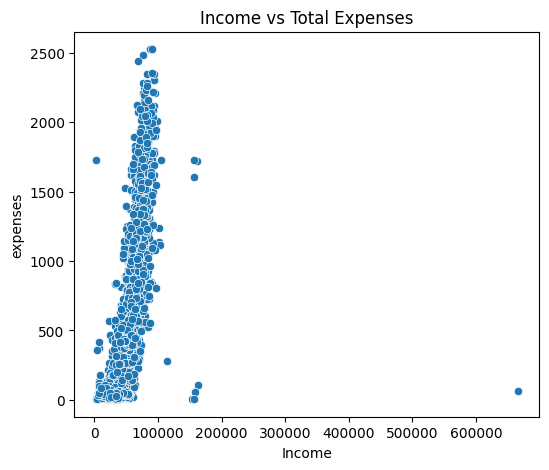

In [30]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='Income',
    y='expenses',
    data=df1
)
plt.title("Income vs Total Expenses")
plt.show()


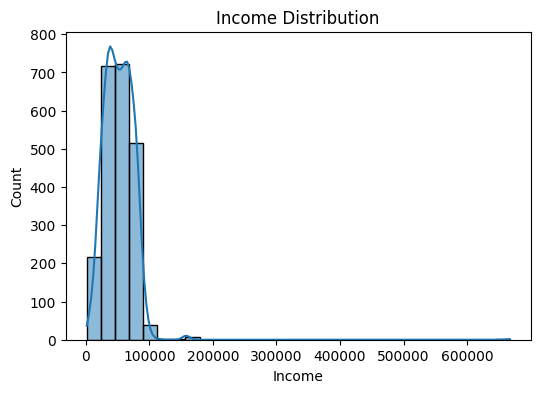

In [31]:
plt.figure(figsize=(6, 4))
sns.histplot(df1['Income'], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()


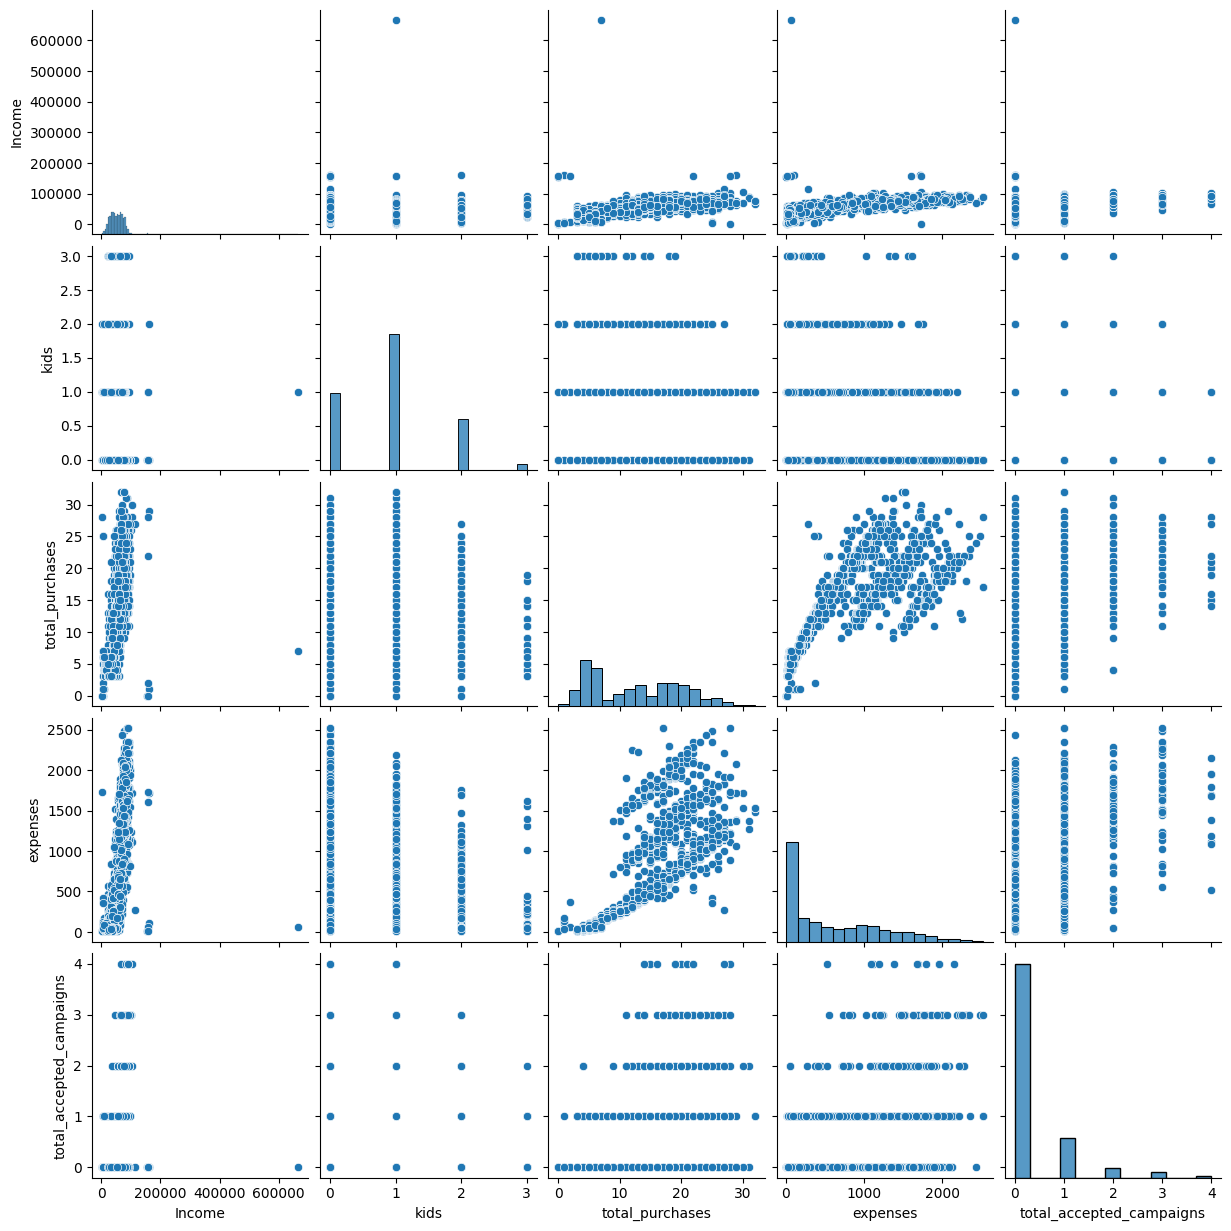

In [32]:
sns.pairplot(df1)
plt.show()


In [ ]:

product_cat = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df_q1 = df[product_cat]
df_q1


,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,58138.0,635,88,546,172,88,88
1,46344.0,11,1,6,2,1,6
2,71613.0,426,49,127,111,21,42
3,26646.0,11,4,20,10,3,5
4,58293.0,173,43,118,46,27,15
...,...,...,...,...,...,...,...
2235,61223.0,709,43,182,42,118,247
2236,64014.0,406,0,30,0,0,8
2237,56981.0,908,48,217,32,12,24
2238,69245.0,428,30,214,80,30,61


How to study this question (Methodological steps)
Step 1: Data preparation

Handle missing income values (drop or impute, justified earlier)

Keep only variables relevant to this question

Step 2: Exploratory analysis

Create income groups (e.g., low / medium / high using quantiles)

Compute average spending per product by income group

Step 3: Visualization

Boxplots or bar charts: income group vs spending

Scatter plots: income vs total expenses

Step 4: Statistical relationship

Pearson correlation (linear relationship)

Spearman correlation (robust to skewness/outliers)

Step 5: Interpretation

Identify which product categories are more income-sensitive

Discuss discretionary vs essential spending

🔹 What you expect to learn

Higher-income customers tend to spend more on non-essential or premium products

Lower-income customers show more stable spending on essentials

### Step1: Handling missing income values

In [34]:
df_q1.isnull().sum()
df_q1 = df_q1.dropna()

In [35]:
df_q1.describe() 

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253
std,25173.076661,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35303.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000
50%,51381.500000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000
75%,68522.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000
max,666666.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000


### STEP 2: Create a Total Spending Variable (Strong Feature Engineering)

In [36]:
df_q1['Total_Spending'] = (
    df_q1['MntWines'] +
    df_q1['MntFruits'] +
    df_q1['MntMeatProducts'] +
    df_q1['MntFishProducts'] +
    df_q1['MntSweetProducts'] +
    df_q1['MntGoldProds']
)


C:\Users\Asus Zenbook\AppData\Local\Temp\ipykernel_22328\731352360.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [37]:
df_q1.describe()


,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,607.075361
std,25173.076661,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,602.900476
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,35303.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,69.000000
50%,51381.500000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,396.500000
75%,68522.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,1048.000000
max,666666.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,2525.000000


the average Income value 52247 in range 1730 to 666666. 
Q2 < Mean : outliers in higher range 

<Axes: ylabel='Total_Spending'>

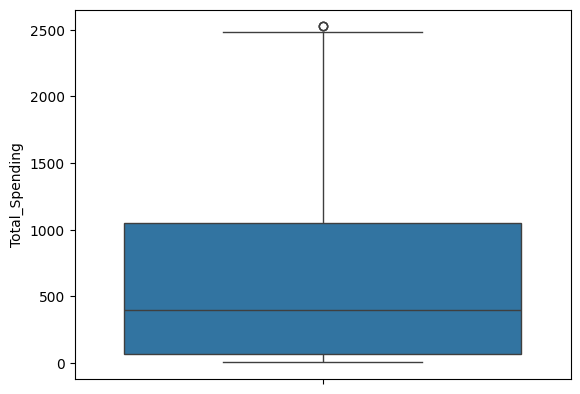

In [ ]:
sns.boxplot(data=df_q1['Total_Spending']) 

<Axes: >

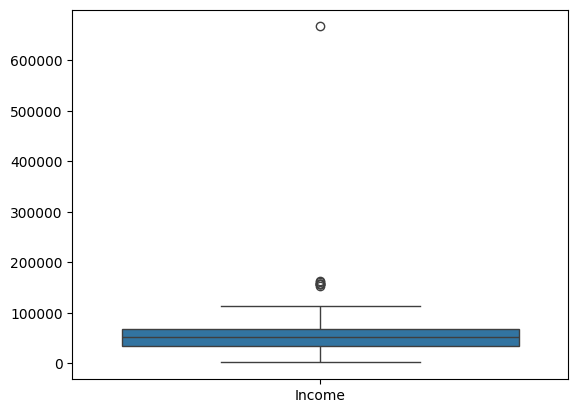

In [39]:
sns.boxplot(data = df_q1[['Income']])

<Axes: xlabel='Income', ylabel='Total_Spending'>

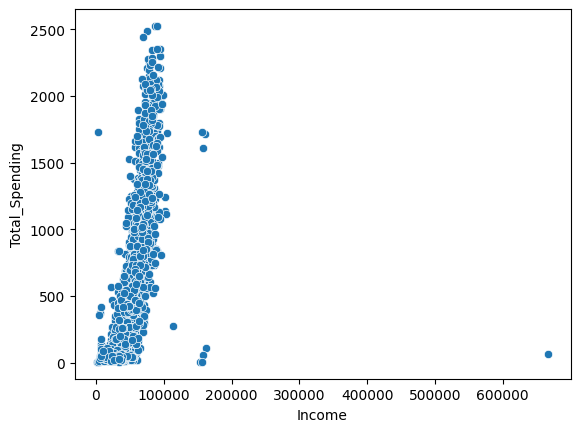

In [40]:
sns.scatterplot(x='Income', y='Total_Spending', data=df_q1)

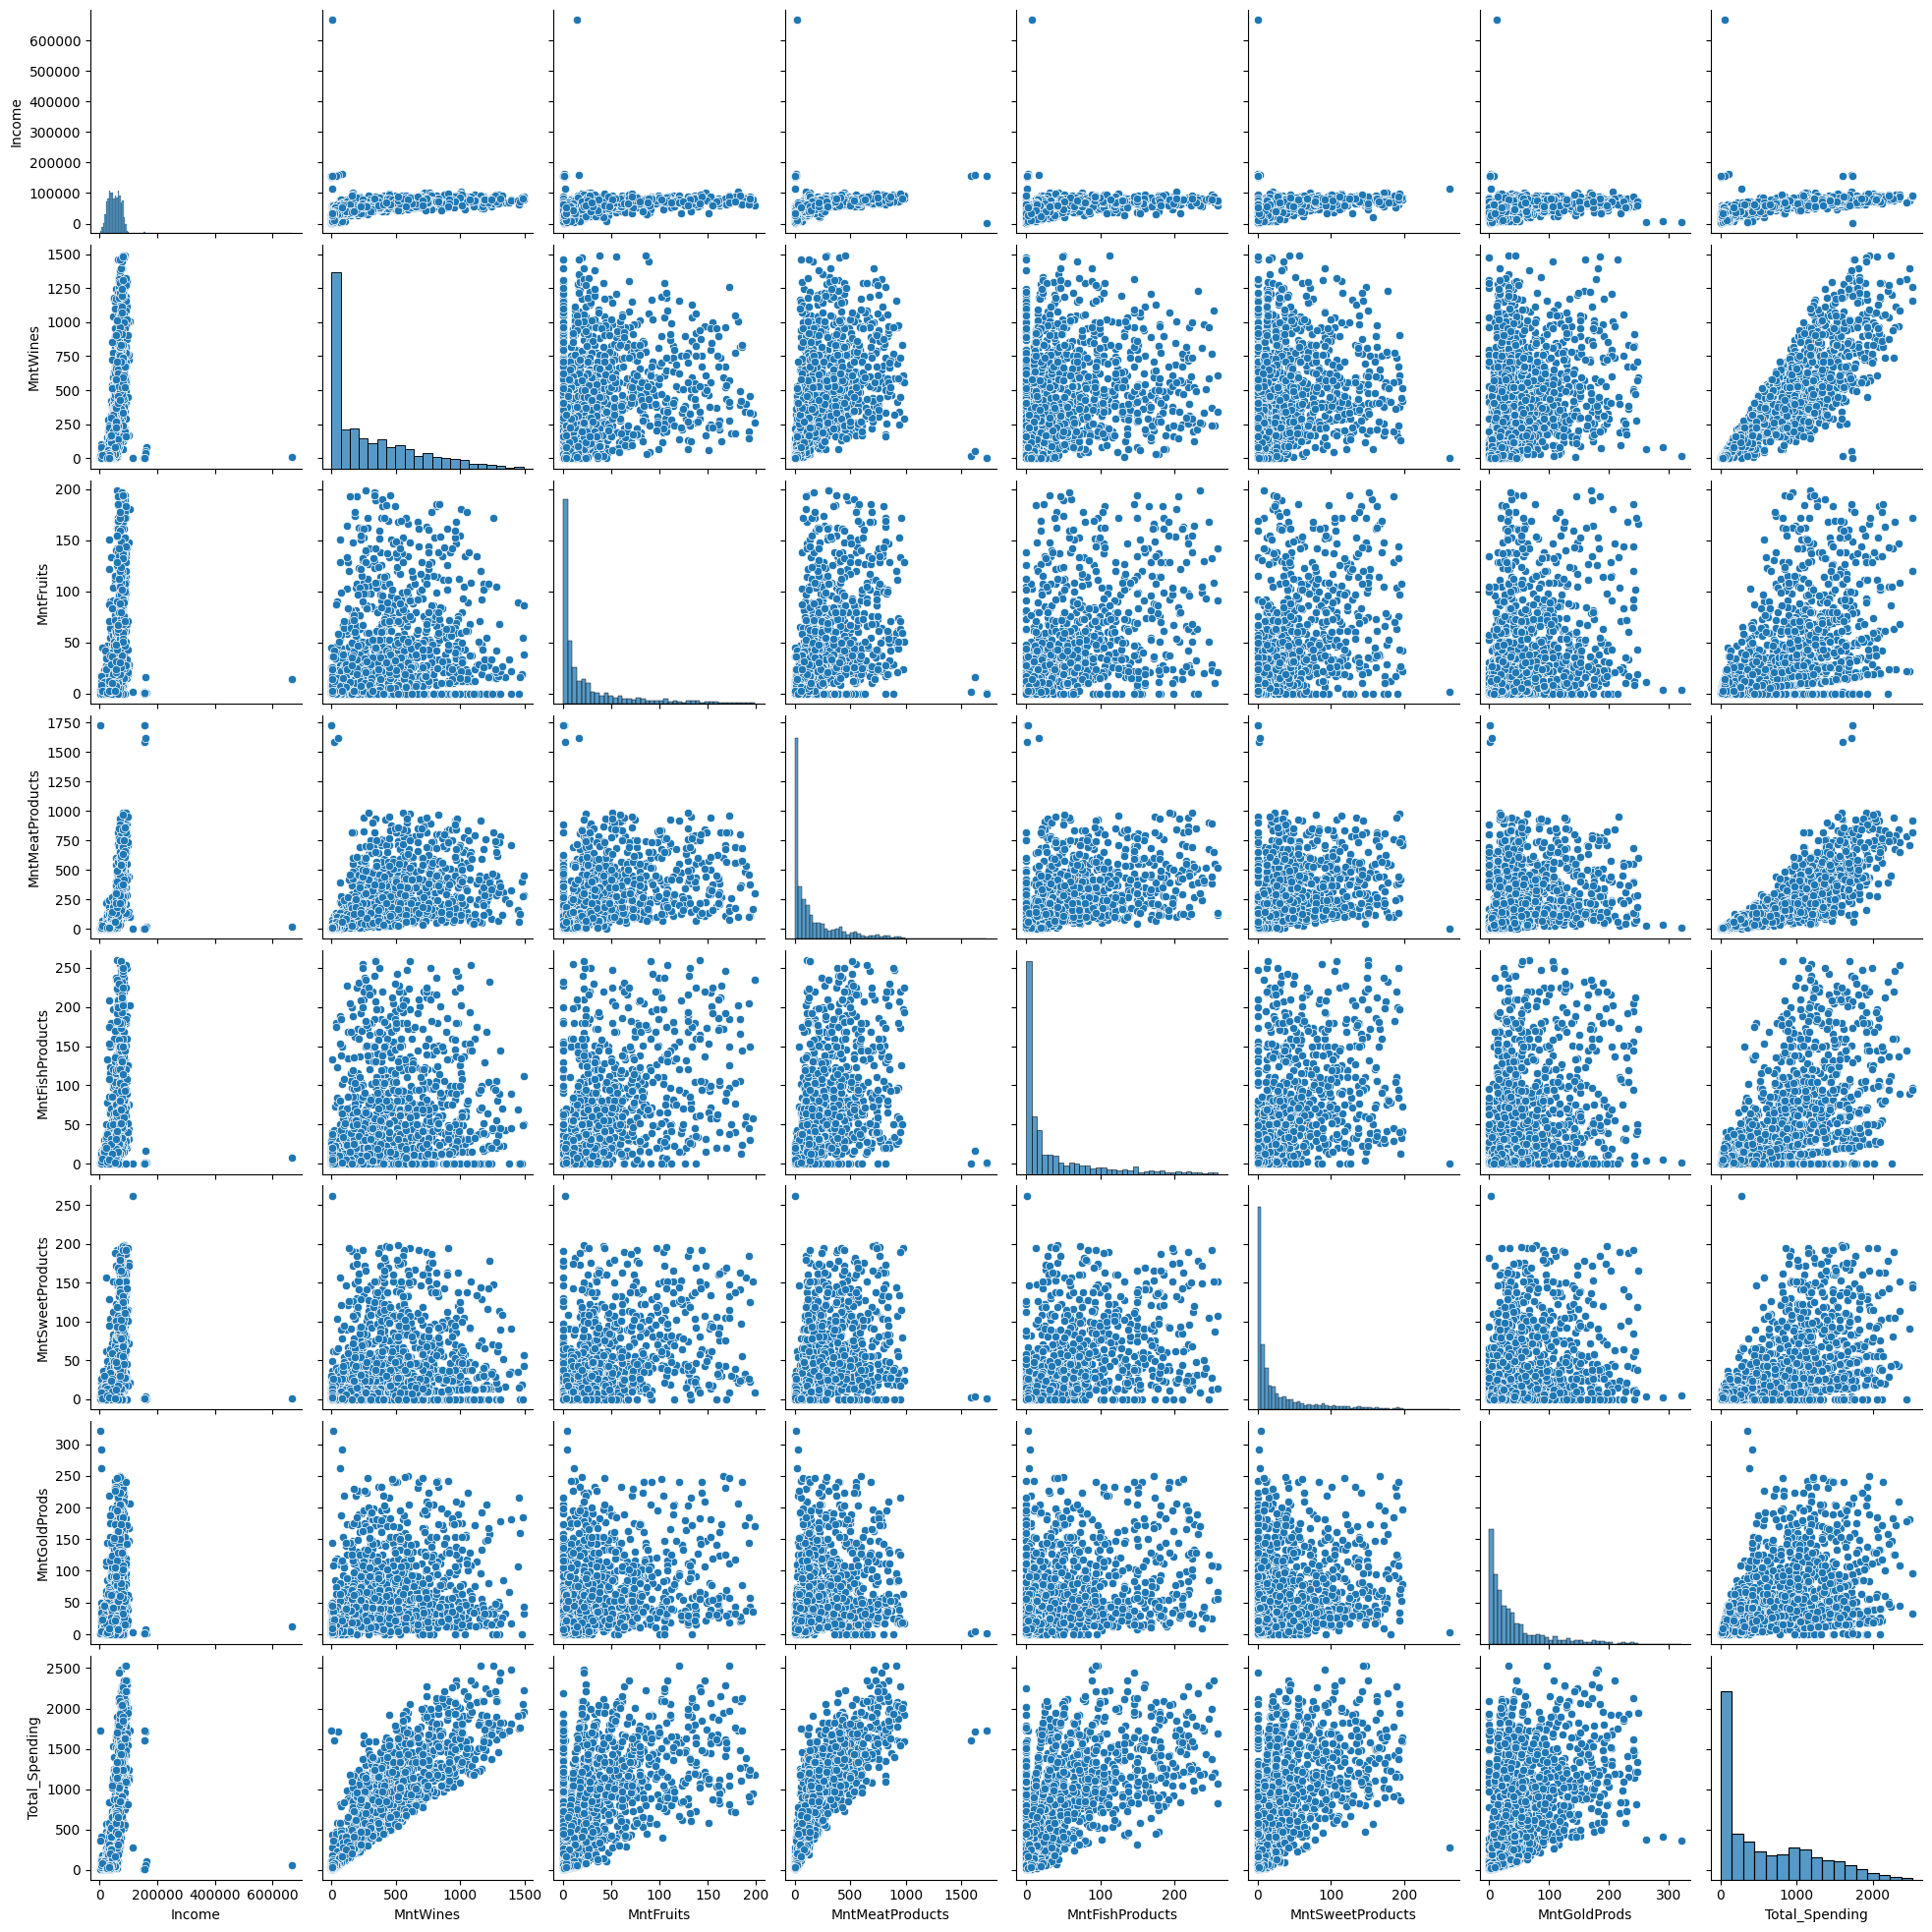

In [41]:
# scatter plot 
sns.pairplot(df_q1)


In [42]:
df_q1['Income_Group'] = pd.qcut(
    df_q1['Income'],
    q=3,
    labels=['Low Income', 'Middle Income', 'High Income']
)


C:\Users\Asus Zenbook\AppData\Local\Temp\ipykernel_22328\2123690904.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [43]:
income_spending_table = (
    df_q1
    .groupby('Income_Group')[[
        'MntWines', 'MntFruits', 'MntMeatProducts',
        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
        'Total_Spending'
    ]]
    .mean()
    .round(2)
)

income_spending_table


C:\Users\Asus Zenbook\AppData\Local\Temp\ipykernel_22328\3247169146.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
Income_Group,,,,,,,
Low Income,30.32,6.01,25.61,9.09,6.07,17.76,94.86
Middle Income,269.07,16.76,89.36,23.56,16.37,43.76,458.89
High Income,615.84,56.29,385.91,80.24,58.63,70.38,1267.28


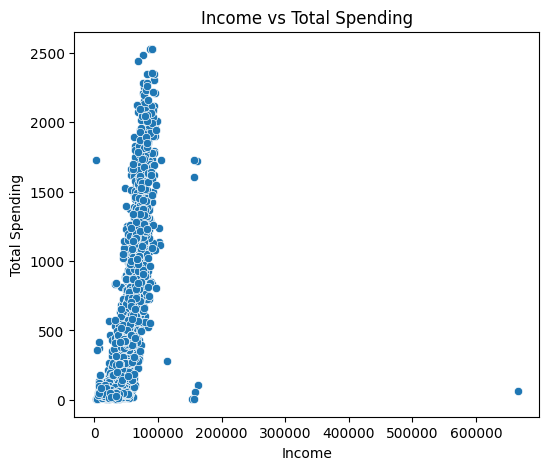

In [44]:

plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='Income',
    y='Total_Spending',
    data=df_q1
)
plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.show()


A positive trend is observed, with higher income customer generally exhibiting higher total spending.

In [45]:
df_q1[['Income', 'Total_Spending']].corr(method='pearson')

,Income,Total_Spending
Income,1.000000,0.667576
Total_Spending,0.667576,1.000000


In [46]:
df_q1[['Income', 'Total_Spending']].corr(method='spearman')

,Income,Total_Spending
Income,1.00000,0.85092
Total_Spending,0.85092,1.00000


In [47]:
corr_matrix = df_q1.drop(columns='Income_Group').corr()
corr_matrix['Income'].sort_values(ascending=False)


Income              1.000000
Total_Spending      0.667576
MntMeatProducts     0.584633
MntWines            0.578650
MntSweetProducts    0.440744
MntFishProducts     0.438871
MntFruits           0.430842
MntGoldProds        0.325916
Name: Income, dtype: float64

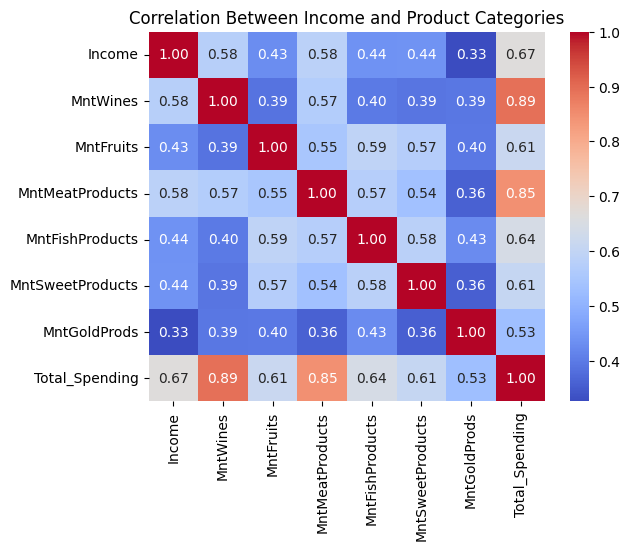

In [48]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Between Income and Product Categories')
plt.show()


In [49]:
# detect outliers using IQR method
Q1 = df_q1['Income'].quantile(0.25)
Q3 = df_q1['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_q1[(df_q1['Income'] < lower_bound) | (df_q1['Income'] > upper_bound)]
outliers

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending,Income_Group
164,157243.0,20,2,1582,1,2,1,1608,High Income
617,162397.0,85,1,16,2,1,2,107,High Income
655,153924.0,1,1,1,1,1,1,6,High Income
687,160803.0,55,16,1622,17,3,4,1717,High Income
1300,157733.0,39,1,9,2,0,8,59,High Income
1653,157146.0,1,0,1725,2,1,1,1730,High Income
2132,156924.0,2,1,2,1,1,1,8,High Income
2233,666666.0,9,14,18,8,1,12,62,High Income


In [50]:

import plotly.express as px

# --- Select columns ---
product_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

df_plot = df[['Income'] + product_cols].dropna().copy()

# --- Create Income Groups (3 groups) ---
df_plot['Income_Group'] = pd.qcut(
    df_plot['Income'],
    q=3,
    labels=['Low Income', 'Middle Income', 'High Income']
)

# --- Convert to long format for plotting ---
df_long = df_plot.melt(
    id_vars=['Income_Group'],
    value_vars=product_cols,
    var_name='Product',
    value_name='Spending'
)

# --- Sort Income_Group order ---
income_order = ['Low Income', 'Middle Income', 'High Income']

# --- Faceted boxplot ---
fig = px.box(
    data_frame=df_long,
    x='Income_Group',
    y='Spending',
    color='Income_Group',
    facet_col='Product',
    category_orders={'Income_Group': income_order},
    points='outliers'   # show outlier points
)

fig.update_layout(
    title="Spending by Product Category Across Income Groups",
    height=450,
    width=1100,
    showlegend=False
)

# Make facet labels nicer
fig.for_each_annotation(lambda a: a.update(text=a.text.replace("Product=", "")))

fig.show()


In [ ]:
# who prefer wine? 

No variables match your requested type.


Across all product categories, median spending increases with income level.
High-income customers consistently show higher central spending values and greater variability, indicating both higher purchasing power and more diverse spending behavior.

- Clear income gradient: Spending generally increases from Low → Middle → High income across all product categories.

- Strongest income effect: Wine and meat show the largest gaps between income groups, indicating these are income-sensitive (discretionary) products.

- Weaker income effect: Fruits and fish have lower medians and smaller differences across groups, suggesting more essential consumption.

- Higher variability at high income: The High Income group shows wider spreads and more high-end outliers, reflecting diverse spending preferences.

### Sub Q1 
**Is there an association between product category spending and customers’ marital status?**

Who prefers? Mariatal_Status vs Product sppending (qual vs quan)

In [52]:

df_q1_1 = df[['Marital_Status'] + product_cols].copy()
df_q1_1 = df_q1_1.dropna(subset=['Marital_Status'] + product_cols)

df_q1_1

,Marital_Status,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,Single,635,88,546,172,88,88
1,Single,11,1,6,2,1,6
2,Together,426,49,127,111,21,42
3,Together,11,4,20,10,3,5
4,Married,173,43,118,46,27,15
...,...,...,...,...,...,...,...
2235,Married,709,43,182,42,118,247
2236,Together,406,0,30,0,0,8
2237,Divorced,908,48,217,32,12,24
2238,Together,428,30,214,80,30,61


In [53]:
valid = ['Single', 'Married', 'Together', 'Divorced', 'Widow']

df_q1_1['Marital_Status_clean'] = df_q1_1['Marital_Status'].where(
    df_q1_1['Marital_Status'].isin(valid), 'Other'
)
df_q1_1

,Marital_Status,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Marital_Status_clean
0,Single,635,88,546,172,88,88,Single
1,Single,11,1,6,2,1,6,Single
2,Together,426,49,127,111,21,42,Together
3,Together,11,4,20,10,3,5,Together
4,Married,173,43,118,46,27,15,Married
...,...,...,...,...,...,...,...,...
2235,Married,709,43,182,42,118,247,Married
2236,Together,406,0,30,0,0,8,Together
2237,Divorced,908,48,217,32,12,24,Divorced
2238,Together,428,30,214,80,30,61,Together


In [54]:
df_long = df_q1_1.melt(
    id_vars='Marital_Status_clean',
    value_vars=product_cols,
    var_name='Product',
    value_name='Spending'
)

fig = px.box(
    df_long,
    x='Marital_Status_clean',
    y='Spending',
    color='Marital_Status_clean',
    facet_col='Product',
    points='outliers'
)

fig.update_layout(
    title='Spending by Product Category across Marital Status',
    height=450,
    width=1100,
    showlegend=False
)

fig.for_each_annotation(lambda a: a.update(text=a.text.replace("Product=", "")))
fig.show()



In [55]:
product_cols = {
    'MntWines': 'Wine',
    'MntFruits': 'Fruits',
    'MntMeatProducts': 'Meat',
    'MntFishProducts': 'Fish',
    'MntSweetProducts': 'Sweets',
    'MntGoldProds': 'Gold'
}
#  Convert to long format (ONE product column)
df_long = df.melt(
    id_vars=['ID', 'Income', 'Marital_Status'],   # keep what you need
    value_vars=list(product_cols.keys()),
    var_name='Product_Code',
    value_name='Spending'
)
# decode 
df_long['Product'] = df_long['Product_Code'].map(product_cols)

df_long[['Product', 'Spending']].head()


,Product,Spending
0,Wine,635
1,Wine,11
2,Wine,426
3,Wine,11
4,Wine,173


In [60]:
df_long_nonzero = df_long[df_long['Spending'] > 0]

In [ ]:
import plotly.express as px

fig = px.box(
    df_long_nonzero,
    x='Marital_Status',
    y='Spending',
    color='Marital_Status',
    animation_frame='Product'   
)

fig.update_layout(
    title='Product Spending by Marital Status',
    height=450,
    width=750,
    showlegend=False
)

fig.show()


# Research Q2: How do household characteristics, especially the presence of children, affect household spending patterns?

IV: kids = kidhome + Tennhome 
- Kidhome – number of young children
- Teenhome – number of teenagers
DV: all product category and total spending

In [67]:
df['kids'].unique()

array([0, 2, 1, 3], dtype=int64)

In [74]:
df['Household_Group'] = pd.cut(
    df['kids'],
    bins=[-1, 0, 1, 2, df['kids'].max()],
    labels=[
        'No Children',
        'One Child',
        'Two Children',
        'Three Children'
    ]
)


In [76]:
spending_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]

df_rq2 = df[['Household_Group'] + spending_cols].dropna()


In [92]:
rq2_summary = (
    df_rq2
    .groupby('Household_Group')[spending_cols]
    .median()
    .round(2)
)

rq2_summary


C:\Users\Asus Zenbook\AppData\Local\Temp\ipykernel_22328\408011157.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Household_Group,,,,,,
No Children,451.0,33.0,363.5,59.0,35.0,42.0
One Child,139.5,6.0,50.0,10.0,7.0,21.0
Two Children,51.0,2.0,21.0,3.0,2.0,13.0
Three Children,33.0,1.0,22.0,3.0,1.0,9.0


In [93]:
import plotly.express as px

df_long_rq2 = df_rq2.melt(
    id_vars='Household_Group',
    value_vars=spending_cols,
    var_name='Product',
    value_name='Spending'
)

fig = px.box(
    df_long_rq2,
    x='Household_Group',
    y='Spending',
    color='Household_Group',
    facet_col='Product',
    points='outliers'
)

fig.update_layout(
    title='Spending by Product Category Across Household Groups',
    height=450,
    width=1100,
    showlegend=False
)

fig.for_each_annotation(lambda a: a.update(text=a.text.replace("Product=", "")))
fig.show()


In [ ]:
# Boxplots show long upper tails & many high-end outliers 
df_rq2.describe().style.background_gradient() 


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875
std,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000
50%,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000
75%,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000
max,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000


In [95]:
df_rq2

,Household_Group,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,No Children,635,88,546,172,88,88
1,Two Children,11,1,6,2,1,6
2,No Children,426,49,127,111,21,42
3,One Child,11,4,20,10,3,5
4,One Child,173,43,118,46,27,15
...,...,...,...,...,...,...,...
2235,One Child,709,43,182,42,118,247
2236,Three Children,406,0,30,0,0,8
2237,No Children,908,48,217,32,12,24
2238,One Child,428,30,214,80,30,61


In [97]:
df_rq2[[
    
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts'
]].skew()


MntWines           1.175771
MntMeatProducts    2.083233
MntFishProducts    1.919769
dtype: float64

In [102]:
df_rq2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Household_Group   2240 non-null   category
 1   MntWines          2240 non-null   int64   
 2   MntFruits         2240 non-null   int64   
 3   MntMeatProducts   2240 non-null   int64   
 4   MntFishProducts   2240 non-null   int64   
 5   MntSweetProducts  2240 non-null   int64   
 6   MntGoldProds      2240 non-null   int64   
dtypes: category(1), int64(6)
memory usage: 107.5 KB


mean > median => skewness
Skewness> 0 => right-skewed   
MEthod to confrim 
    - Kruskal–Wallis 
    - Spearman 
 

In [103]:
q2corr = df_rq2.select_dtypes(exclude='category')
q2corr.corr(method='spearman')

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
MntWines,1.000000,0.517544,0.823652,0.524609,0.505322,0.575345
MntFruits,0.517544,1.000000,0.713169,0.705016,0.691356,0.568750
MntMeatProducts,0.823652,0.713169,1.000000,0.726242,0.695704,0.637912
MntFishProducts,0.524609,0.705016,0.726242,1.000000,0.700871,0.565283
MntSweetProducts,0.505322,0.691356,0.695704,0.700871,1.000000,0.542963
MntGoldProds,0.575345,0.568750,0.637912,0.565283,0.542963,1.000000


- statistical test: Kruskal–Wallis test Because data is skewed 

In [96]:
from scipy.stats import kruskal

results = []

for prod in spending_cols:
    samples = [
        df_rq2.loc[df_rq2['Household_Group'] == g, prod]
        for g in df_rq2['Household_Group'].unique()
    ]
    H, p = kruskal(*samples)
    results.append([prod, H, p])

rq2_test = pd.DataFrame(
    results,
    columns=['Product', 'Kruskal_H', 'p_value']
).sort_values('p_value')

rq2_test


,Product,Kruskal_H,p_value
2,MntMeatProducts,577.729328,6.779886e-125
3,MntFishProducts,564.475190,5.061738e-122
1,MntFruits,503.238673,9.479779e-109
4,MntSweetProducts,483.815640,1.534418e-104
0,MntWines,263.283355,8.760682e-57
5,MntGoldProds,228.646158,2.713481e-49


Interpretation: 
For all product categories, the Kruskal–Wallis test shows statistically significant differences in spending across the four household groups (all p-values ≪ 0.05).

The strongest household effect is observed for meat, fish, fruits, and sweet products (largest Kruskal H values), indicating that spending on these items varies most with the presence/number of children.

Wine and gold products also differ significantly across household groups, but with relatively smaller H values, suggesting a weaker (though still meaningful) association with household composition.

`Result and Insight:`
Household structure especially the number of children is strongly associated with how households allocate spending. Larger or child-present households show systematically different spending patterns, particularly for food-related categories, while discretionary items (wine, gold) are less sensitive but still affected.

# Research Q3: What distinct customer segments can be identified using PCA and k-means clustering based on income, household characteristics, and purchasing behavior?